In [1]:
import pandas as pd
import os
import calendar

# Conversion factor from cubic meters to barrels
M3_TO_BBL = 6.28981

# Base path for simulations
base_path = "C:/Users/calva/OneDrive/Documentos/Doutorado/benchmark/OPM_Egg"

# List of simulation folder names
num_simulations = 101
sim_names = [f"simulacao_{i}" for i in range(num_simulations)]

# Wells of interest
wells = ["PROD1", "PROD2", "PROD3", "PROD4", "INJECT1"]

# Initialize a DataFrame to store production per simulation and well
matrix = pd.DataFrame(index=sim_names, columns=wells)

# Iterate through all simulation folders
for sim in sim_names:
    csv_path = os.path.join(base_path, sim, "EGG_MODEL_ECL_production.csv")
    
    if not os.path.isfile(csv_path):
        print(f"❌ CSV not found: {csv_path}")
        continue
    
    try:
        # Load CSV and set the DATE column as index
        df = pd.read_csv(csv_path, parse_dates=["DATE"])
        df.set_index("DATE", inplace=True)

        # Add a column with the number of days in each month
        df["days_in_month"] = df.index.daysinmonth

        # Multiply each rate by days in the month to get monthly volume in m³,
        # then convert from m³ to BBL
        rate_cols = [col for col in df.columns if ":" in col]
        for col in rate_cols:
            df[col] = df[col] * df["days_in_month"]  # Monthly volume in m³
            df[col] = df[col] * M3_TO_BBL            # Monthly volume in BBL

        # Aggregate monthly volumes into annual totals
        df_yearly = df[rate_cols].resample("YE").sum()
        df_yearly.index = df_yearly.index.year  # Keep only the year for clarity

        # Store annual production per well
        for well in wells:
            if "INJECT" in well:
                # For injector wells: use WWIR only
                col_name = f"WWIR:{well}"
                if col_name in df_yearly.columns:
                    matrix.at[sim, well] = df_yearly[[col_name]]
            else:
                # For producer wells: use WLPR, WOPR, WWPR
                cols = [f"{var}:{well}" for var in ["WLPR", "WOPR", "WWPR"] if f"{var}:{well}" in df_yearly.columns]
                if cols:
                    matrix.at[sim, well] = df_yearly[cols]

    except Exception as e:
        print(f"⚠️ Error reading {csv_path}: {e}")


In [2]:
import pandas as pd

producer_wells = ["PROD1", "PROD2", "PROD3", "PROD4"]
years = list(range(11))  # 0 to 10

sim_names = [f"simulacao_{i}" for i in range(101)]
field_matrix = pd.DataFrame(index=years, columns=sim_names)

# Supondo que você tem o ano inicial, por exemplo 2011
ano_inicial = 2011

for sim in sim_names:
    total_curve = pd.Series(0.0, index=years)
    
    for well in producer_wells:
        well_df = matrix.at[sim, well]

        if isinstance(well_df, pd.DataFrame) and f"WOPR:{well}" in well_df.columns:
            wopr_series = well_df[f"WOPR:{well}"]
            # O índice de wopr_series deve ser ano-calendário
            for i, year in enumerate(years):
                ano_calendario = ano_inicial + year
                if ano_calendario in wopr_series.index:
                    total_curve[year] += wopr_series[ano_calendario]
    
    field_matrix[sim] = total_curve

field_matrix = field_matrix.astype(float)



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


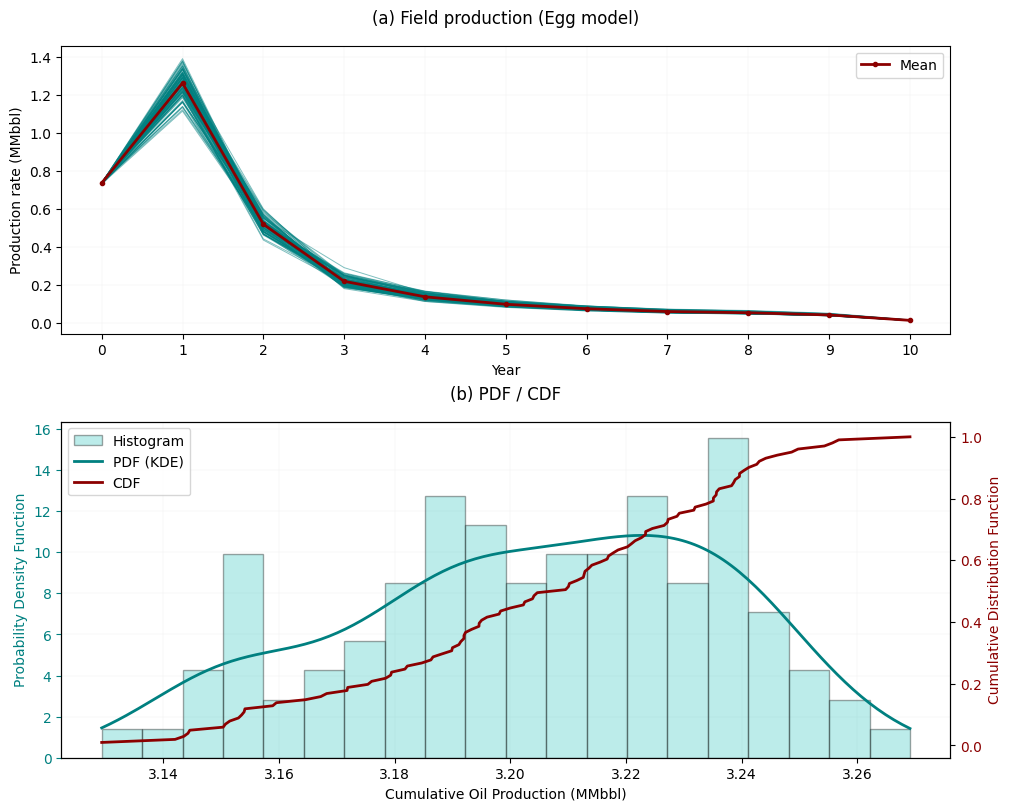

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

def plot_field_summary(field_matrix, simulations="all", years="all", show_cdf=True):
    """
    Plots 2x1 subplots:
    (a) Field production curves (all simulations + mean).
    (b) Histogram + KDE (PDF) + CDF of cumulative production.
    Subtitles (a) and (b) appear above each subplot.
    """
    # --- Select simulations ---
    years_idx = field_matrix.index
    if simulations == "all":
        selected_sims = field_matrix.columns.tolist()
    elif isinstance(simulations, str) and "-" in simulations:
        start, end = map(int, simulations.split("-"))
        selected_sims = [f"simulacao_{i}" for i in range(start, end + 1)]
    elif isinstance(simulations, list):
        selected_sims = [f"simulacao_{i}" for i in simulations]
    else:
        raise ValueError("Invalid simulations input.")

    # --- Select years for cumulative ---
    if years == "all":
        selected_matrix = field_matrix[selected_sims]
        years_sel = years_idx
    elif isinstance(years, list):
        selected_matrix = field_matrix.loc[years, selected_sims]
        years_sel = years
    elif isinstance(years, str) and "-" in years:
        start, end = map(int, years.split("-"))
        selected_matrix = field_matrix.loc[start:end, selected_sims]
        years_sel = list(range(start, end + 1))
    else:
        raise ValueError("Invalid years argument.")

    # --- Cumulative production ---
    cumulative = selected_matrix.sum(axis=0) / 1e6  # MMbbl
    cumulative_sorted = np.sort(cumulative.values)

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), 
        gridspec_kw={'height_ratios': [1.2, 1.4]},
        constrained_layout=True)

    # --- (a) Production curves ---
    ax1 = axes[0]
    for sim in selected_sims:
        if sim in field_matrix.columns:
            ax1.plot(years_idx, field_matrix[sim]/1e6, color="teal", lw=0.7, alpha=0.5)
    mean_curve = field_matrix[selected_sims].mean(axis=1) / 1e6
    ax1.plot(years_idx, mean_curve, color="darkred", lw=2, marker='.', label="Mean")
    ax1.set_xlabel("Year")
    ax1.set_ylabel("Production rate (MMbbl)")
    ax1.set_xticks(years_idx)
    ax1.ticklabel_format(style='plain', axis='y')
    ax1.legend(fontsize=10)
    ax1.grid(color="0.94", lw=0.3)
    ax1.set_axisbelow(True)  # Grid behind lines
    # Subtítulo acima do gráfico
    ax1.set_title("(a) Field production (Egg model)", loc='center', fontsize=12, pad=16)

    # --- (b) Histogram + KDE + CDF ---
    ax2 = axes[1]
    counts, bins, patches = ax2.hist(
        cumulative, bins=20, color="#40c9c3", alpha=0.35, edgecolor="black",
        density=True, label="Histogram"
    )
    kde = gaussian_kde(cumulative)
    x_grid = np.linspace(min(cumulative), max(cumulative), 200)
    ax2.plot(x_grid, kde(x_grid), color="teal", lw=2, label="PDF (KDE)")
    if show_cdf:
        ax22 = ax2.twinx()
        y_cdf = np.arange(1, len(cumulative_sorted)+1) / len(cumulative_sorted)
        ax22.plot(
            cumulative_sorted, y_cdf, color="darkred", lw=2, label="CDF"
        )
        ax22.set_ylabel("Cumulative Distribution Function", color="darkred")
        ax22.tick_params(axis='y', labelcolor="darkred")
        lines1, labels1 = ax2.get_legend_handles_labels()
        lines2, labels2 = ax22.get_legend_handles_labels()
        ax22.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)
    else:
        ax2.legend(loc="upper left", fontsize=10)
    ax2.set_xlabel("Cumulative Oil Production (MMbbl)")
    ax2.set_ylabel("Probability Density Function")
    ax2.grid(color="0.94", lw=0.3)
    ax2.set_axisbelow(True)
    # Subtítulo acima do gráfico
    ax2.set_title("(b) PDF / CDF", loc='center', fontsize=12, pad=16)

    # Y-label e ticks do PDF em teal
    ax2.yaxis.label.set_color("teal")
    ax2.tick_params(axis='y', colors="teal")

    output_path = r"C:\Users\calva\OneDrive\Documentos\Doutorado\paper_com_Bratvold\sn-article-template\production_field_pdf_cdf.eps"
    plt.savefig(output_path, format="eps", dpi=300)
    plt.show()

    return mean_curve

# Exemplo de uso:
mean_curve = plot_field_summary(field_matrix)